In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [4]:
path = "../results"

micro_file_list = ["160_10-layer_mn.npy","160_10-layer_nn.npy"]
descriptor_file_list = ["160_10-layer_mn_characterization.pickle","160_10-layer_nn_characterization.pickle"]

In [9]:
def resample_S2_descriptor(descriptor_value):
    x_max, y_max = descriptor_value.shape
    assert x_max == y_max
    limit_to = np.round(0.5 + np.sqrt(0.5 * x_max - 0.25), decimals=0).astype(int)

    s2_descriptor = np.diag(descriptor_value)
    s2_sorted = np.zeros(tuple([2 * limit_to - 1]*2))
    k = 0
    for i in range(limit_to):
        for j in range(limit_to):
            s2_sorted[limit_to - 1 + i, limit_to - 1 + j] = s2_descriptor[k]
            s2_sorted[limit_to - 1 - i, limit_to - 1 - j] = s2_descriptor[k]
            k += 1
    for i in range(1, limit_to):
        for j in range(1, limit_to):
            s2_sorted[limit_to - 1 + i, limit_to - 1 - j] = s2_descriptor[k]
            s2_sorted[limit_to - 1 - i, limit_to - 1 + j] = s2_descriptor[k]
            k += 1
    return s2_sorted

10.602525994849241 12.958793656964412
4.922342249052137 5.139301627437999


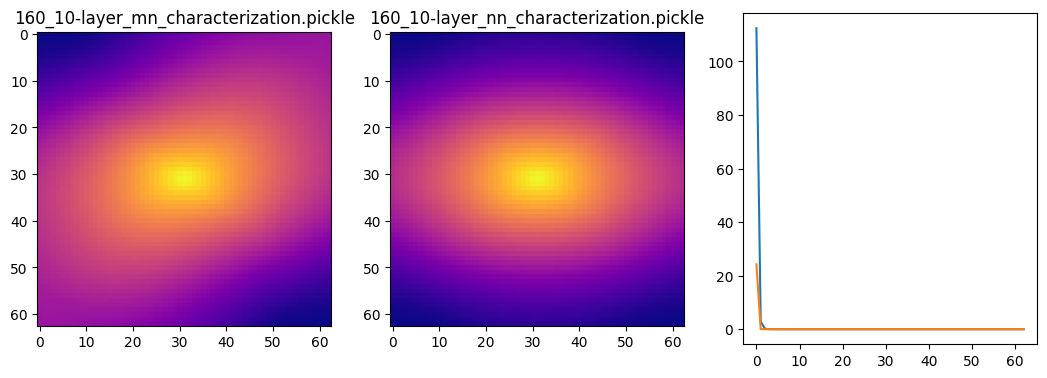

In [43]:
fig, axs = plt.subplots(1,3,figsize=(3*4.3,4.3))

axs = np.array(axs).flatten()

for i, (micro_file, descriptor_file) in enumerate(zip(micro_file_list,descriptor_file_list)):
    micro_file = np.load(os.path.join(path,micro_file))
    with open(os.path.join(path,descriptor_file),"rb") as f:
        descriptor_dict = pickle.load(f)

        if "Correlations" in descriptor_dict.keys():
            descriptor_value = descriptor_dict["Correlations"][0][1,1,::]

            s2_sorted = resample_S2_descriptor(descriptor_value)

            axs[i].imshow(s2_sorted,cmap = "plasma")
            axs[i].set_title(descriptor_file)
            U, s, Vh = np.linalg.svd(s2_sorted)
            axs[2].plot(s**2)

            print(s.max(),np.sum(s))

# Singluar Value Decompostion

$$ A = USV^H$$

with $A$

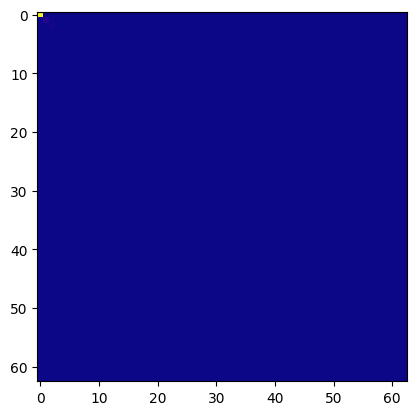

In [29]:
plt.imshow(np.diag(s),cmap="plasma")


In [82]:
for key, item in descritpor.items():
    print(key,type(item))

Correlations <class 'tuple'>
Variation <class 'tuple'>
settings <class 'mcrpy.src.Settings.CharacterizationSettings'>


In [ ]:


for i in range(len(descritpor["Correlations"])):
    print(descritpor["Correlations"][i].shape)

descriptor_value= 

mg_level =1
n_phase = 0

(3, 2, 1985, 1985)
(3, 2, 1985, 1985)
(3, 2, 1985, 1985)


1985 1985


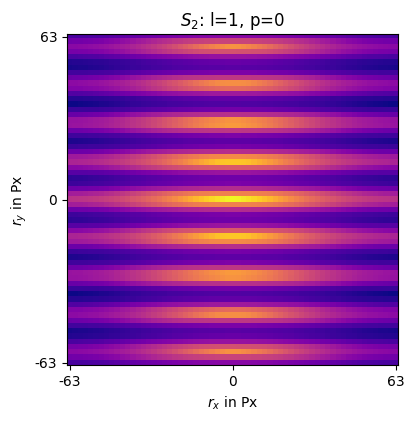

In [92]:
fig,ax = plt.subplots(1,1,figsize = (4.3,4.3))

ax= np.array(ax).flatten()
x_max, y_max = descriptor_value.shape
print(x_max,y_max)
assert x_max == y_max
limit_to = np.round(0.5 + np.sqrt(0.5 * x_max - 0.25), decimals=0).astype(int)

s2_descriptor = np.diag(descriptor_value)
s2_sorted = np.zeros(tuple([2 * limit_to - 1]*2))
k = 0
for i in range(limit_to):
    for j in range(limit_to):
        s2_sorted[limit_to - 1 + i, limit_to - 1 + j] = s2_descriptor[k]
        s2_sorted[limit_to - 1 - i, limit_to - 1 - j] = s2_descriptor[k]
        k += 1
for i in range(1, limit_to):
    for j in range(1, limit_to):
        s2_sorted[limit_to - 1 + i, limit_to - 1 - j] = s2_descriptor[k]
        s2_sorted[limit_to - 1 - i, limit_to - 1 + j] = s2_descriptor[k]
        k += 1
ax[0].imshow(s2_sorted, cmap='plasma')
xticks = [0, limit_to - 1, 2 * (limit_to - 1)]
yticks = [0, limit_to - 1, 2 * (limit_to - 1)]

ax[0].set_title(f'$S_2$: l={mg_level}, p={n_phase}')
ax[0].set_xlabel(r'$r_x$ in Px')
ax[0].set_ylabel(r'$r_y$ in Px')
ax[0].set_xticks(xticks)
ax[0].set_yticks(yticks)
ax[0].set_xticklabels([-(2**mg_level * limit_to) + 1, 0, 2**mg_level * limit_to - 1])
ax[0].set_yticklabels(reversed([-(2**mg_level * limit_to) + 1, 0, 2**mg_level * limit_to - 1]))
plt.show()

In [95]:
U, s, Vh = np.linalg.svd(s2_sorted)

print(U.shape,s.shape,Vh.shape)

print(s)

(63, 63) (63,) (63, 63)
[2.57955311e+01 4.88383686e-01 1.12832626e-01 2.87899439e-02
 9.59876209e-03 8.14796970e-03 3.80843956e-03 2.45084463e-03
 1.87051768e-03 1.56553291e-03 1.21341696e-03 1.04438961e-03
 6.94830635e-04 5.51101165e-04 4.63541384e-04 3.74520213e-04
 2.73796597e-04 2.21526009e-04 2.01279456e-04 1.72705568e-04
 1.54167876e-04 1.34861482e-04 1.12233672e-04 9.26210243e-05
 5.93107360e-05 5.03863232e-05 4.72652887e-05 4.16336614e-05
 4.05814053e-05 3.05713793e-05 2.25548649e-05 1.99547239e-05
 1.84030582e-05 1.74330801e-05 1.56595835e-05 1.52920485e-05
 1.36018290e-05 1.28391740e-05 1.08873725e-05 9.86707214e-06
 8.87747960e-06 8.68557835e-06 8.37893837e-06 8.22361200e-06
 7.79288363e-06 6.33362892e-06 6.13723318e-06 5.46394485e-06
 5.32901261e-06 4.93121865e-06 4.11762422e-06 3.99804718e-06
 3.61955711e-06 2.86410255e-06 2.63292272e-06 2.38588384e-06
 1.72034521e-06 1.51239144e-06 1.48823961e-06 1.17848973e-06
 7.90604866e-07 5.46751548e-07 2.68546998e-07]


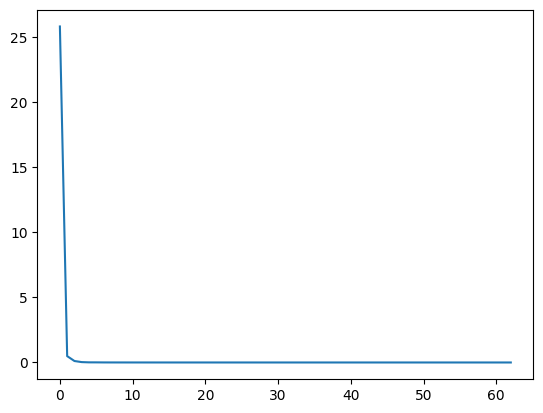

In [96]:
plt.plot(s)

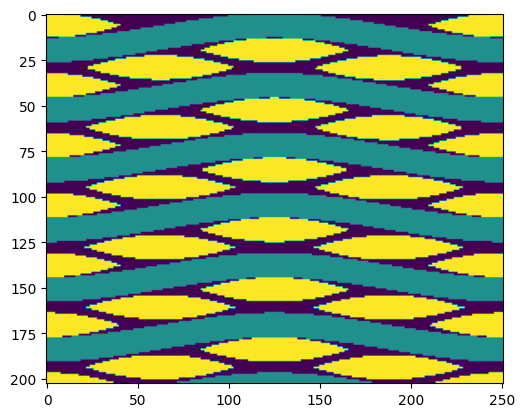

In [6]:
plt.imshow(structure[:,0,:])